# CORGI M-R curve tutorial
This Jupyter notebook walks through how to generate constant composition mass-radius (M-R) curves with `CORGI`.

In [1]:
# import CORGI modules
import simpleMR as smr # where most calculation happens
import EOS as eos # equation of state (EOS) calculations
import generate_MR_curves as genmr

# import other modules
import datetime
import numpy as np
from tqdm.notebook import tqdm
import sys, os
import pandas as pd

# import matplotlib and set plotting styles
from matplotlib import pyplot as plt
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['mathtext.fontset'] = 'stix'
from matplotlib.ticker import MultipleLocator, AutoLocator, AutoMinorLocator
from matplotlib import colors
import matplotlib.cm as cm

Loading Seager et al. 2007 H2O EOS ...
Completed

Loading Zeng et al. 2021 H2O EOS ...
Completed

Loading Seager et al. 2007 Fe EOS ...
Completed

Loading Zeng et al. 2016 core EOS ...
Completed

Loading Zeng et al. 2021 core EOS ...
Completed

Loading Smith et al. 2018 solid iron EOS ...
Completed

Loading Grant et al. 2021 liquid iron EOS ...
Completed

Loading Seager et al. 2007 MgSiO3 (en) EOS ...
Completed

Loading Seager et al. 2007 MgSiO3 (pv) EOS ...
Completed

Loading Hubbard & Marley 1989 analytical rock EOS ...
Completed

Loading Seager et al. 2007 MgSiO3 (iron-rich pv) EOS ...
Completed

Loading Zeng et al. 2016 mantle EOS ...
Completed

Loading Zeng et al. 2021 mantle EOS ...
Completed

Loading Oganov & Ono 2004 MgSiO3 (ppv) EOS ...
Completed

Loading Seager et al. (2007) carbon (graphite) EOS ...
Completed

Loading Swift et al. (2022) carbon (diamond) EOS ...
Completed

Loading SiC zinc-blende structure EOS ...
Completed

Loading SiC rock-salt structure EOS ...
Completed


In [2]:
# potentially useful constants in SI
c = 299792458.0 # speed of light in m / s
h = 6.62607015e-34 # Planck's constant in m2 kg / s
G = 6.67430e-11  # gravitational constant, https://physics.nist.gov/cgi-bin/cuu/Value?bg
Re = 6371000.0  # Earth radius
Me = 5.9722e24  # Earth mass, https://nssdc.gsfc.nasa.gov/planetary/factsheet/earthfact.html
Rjup = 69911 * 1.0e3
Mjup = 1898.13e24 
kb = 1.380649e-23 # Boltzmann constant, J/K
massH = 1.66053906660e-27 # mass of H atom in kg
sigma_SB = 5.670374419e-8 # Stefan–Boltzmann constant in W m-2 K-4
Msun = 1.989e+30
Rsun = 6.957e+8
AU = 1.496e+11
AU_cgs = 1.496e+11 * 100.0
seconds_in_day = 24 * 3600.0
solar_constant = 1361.0 # W/m2

# (1) Homogeneous planets
Here, I generate some M-R curves for planets with homogeneous compositions, i.e., planets that are consisted of pure iron, pure silicate, or pure water.

This is done by calling functions from generate_MR_curves.py

In [3]:
pcs = np.logspace(np.log10(1.0e8), np.log10(1.0e14), 20) # array of central pressures in Pa
print(pcs)

[1.00000000e+08 2.06913808e+08 4.28133240e+08 8.85866790e+08
 1.83298071e+09 3.79269019e+09 7.84759970e+09 1.62377674e+10
 3.35981829e+10 6.95192796e+10 1.43844989e+11 2.97635144e+11
 6.15848211e+11 1.27427499e+12 2.63665090e+12 5.45559478e+12
 1.12883789e+13 2.33572147e+13 4.83293024e+13 1.00000000e+14]


In [4]:
# pure iron planet, using Zeng et al. (2016) iron EOS
genmr.MR_curve_homogeneous("iron", pcs)

100%|████████████████████████████████████████████████████████████| 20/20 [00:16<00:00,  1.23it/s]


In [5]:
# pure silicate planet, using Zeng et al. (2016) silicate EOS
genmr.MR_curve_homogeneous("silicate", pcs)

100%|████████████████████████████████████████████████████████████| 20/20 [00:28<00:00,  1.43s/it]


In [6]:
# pure water planet, using the AQUA water EOS
genmr.MR_curve_homogeneous("water", pcs)

100%|████████████████████████████████████████████████████████████| 20/20 [00:10<00:00,  1.97it/s]


Now, we have three files: 
- MR_curve_rocky_Zeng2016EOS_cmf100.txt
- MR_curve_rocky_Zeng2016EOS_cmf000.txt
- MR_curve_water_AQUAEOS.txt

each containing M-R for homogeneous planets with pure iron, pure silicate, and pure water compositions, respectively. Let's plot the M-R curves.

In [7]:
corgi_mr_cmf00 = np.genfromtxt("Results/MR_curve_rocky_Zeng2016EOS_cmf000.txt", skip_header=1)
corgi_mr_cmf10 = np.genfromtxt("Results/MR_curve_rocky_Zeng2016EOS_cmf100.txt", skip_header=1)
corgi_mr_water = np.genfromtxt("Results/MR_curve_water_AQUAEOS.txt", skip_header=1)

mr_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', 
             '#bcbd22', '#17becf']

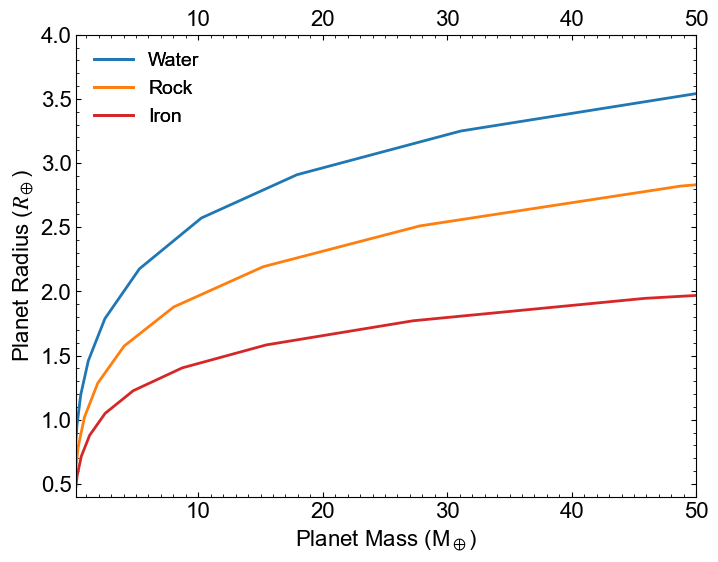

In [8]:
# plot CORGI M-R curves and the rho_HD curve
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# pure water
ax.plot(corgi_mr_water[:,1], corgi_mr_water[:,2], lw=2, label="Water", color=mr_colors[0])

# pure rock
ax.plot(corgi_mr_cmf00[:,1], corgi_mr_cmf00[:,2], lw=2, label="Rock", color=mr_colors[1])

# pure iron
ax.plot(corgi_mr_cmf10[:,1], corgi_mr_cmf10[:,2], lw=2, label="Iron", color=mr_colors[3])

legend1 = plt.legend(loc="upper left", fontsize=14, fancybox=True, framealpha=0)
ax.add_artist(legend1)  # keep this legend when adding another

ax.set_xlim([0.2, 50])
ax.set_ylim([0.4, 4.0])
ax.set_xlabel(r'Planet Mass (M$_\oplus$)', fontsize=16)
ax.set_ylabel(r'Planet Radius ($R_\oplus$)', fontsize=16)
ax.tick_params(axis='both', which='both', labelsize=16, top=True, right=True, direction='in', 
                   labeltop=True)
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))

plt.show()
plt.close()

Looks good! By increasing the resolution of pcs, we can get smoother M-R curves, but the run will take longer.

# (2) Two-layer planets
Now, let's run two-layer planets with either rock+water or iron+rock compositions. 

In [9]:
# an array of masses to simulate
marr = np.concatenate((np.linspace(0.1, 1, 4), np.linspace(1, 5, 5)[1:], np.linspace(5, 20, 4)[1:]))
marr *= Me

In [10]:
# run M-R curves with 2 layers; this will take a while, so uncomment and run it when you have time
# genmr.MR_curve_2layer(marr)

# (3) Plot the results
Here, I'm plotting pre-generated M-R curves with more data points, so that the plot looks better.

I'm also showing the M-R of known exoplanets for comparison.

In [11]:
data_planets = pd.read_csv("Data/CombinedDatabase_PlanetS_NEA_20251022_processed.csv", delimiter=",")

In [12]:
# read in CORGI M-R curves
corgi_indir = "./MR_curves/Zeng2016EOS_2layer_rocky/"
corgi_mr_cmf00 = np.genfromtxt(corgi_indir + "MR_curve_rocky_Zeng2016EOS_cmf000.txt", skip_header=1)
corgi_mr_cmf01 = np.genfromtxt(corgi_indir + "MR_curve_rocky_Zeng2016EOS_cmf010.txt")
corgi_mr_cmf02 = np.genfromtxt(corgi_indir + "MR_curve_rocky_Zeng2016EOS_cmf020.txt")
corgi_mr_cmf03 = np.genfromtxt(corgi_indir + "MR_curve_rocky_Zeng2016EOS_cmf030.txt")
corgi_mr_cmf04 = np.genfromtxt(corgi_indir + "MR_curve_rocky_Zeng2016EOS_cmf040.txt")
corgi_mr_cmf05 = np.genfromtxt(corgi_indir + "MR_curve_rocky_Zeng2016EOS_cmf050.txt")
corgi_mr_cmf06 = np.genfromtxt(corgi_indir + "MR_curve_rocky_Zeng2016EOS_cmf060.txt")
corgi_mr_cmf07 = np.genfromtxt(corgi_indir + "MR_curve_rocky_Zeng2016EOS_cmf070.txt")
corgi_mr_cmf08 = np.genfromtxt(corgi_indir + "MR_curve_rocky_Zeng2016EOS_cmf080.txt")
corgi_mr_cmf09 = np.genfromtxt(corgi_indir + "MR_curve_rocky_Zeng2016EOS_cmf090.txt")
corgi_mr_cmf10 = np.genfromtxt(corgi_indir + "MR_curve_rocky_Zeng2016EOS_cmf100.txt", skip_header=1)
corgi_mr_water = np.genfromtxt(corgi_indir + "MR_curve_water_AQUAEOS.txt", skip_header=1)
corgi_mr_50rock_50water = np.genfromtxt(corgi_indir + "MR_curve_rocky_Zeng2016EOS_50rock_50water.txt")

mr_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', 
             '#bcbd22', '#17becf']

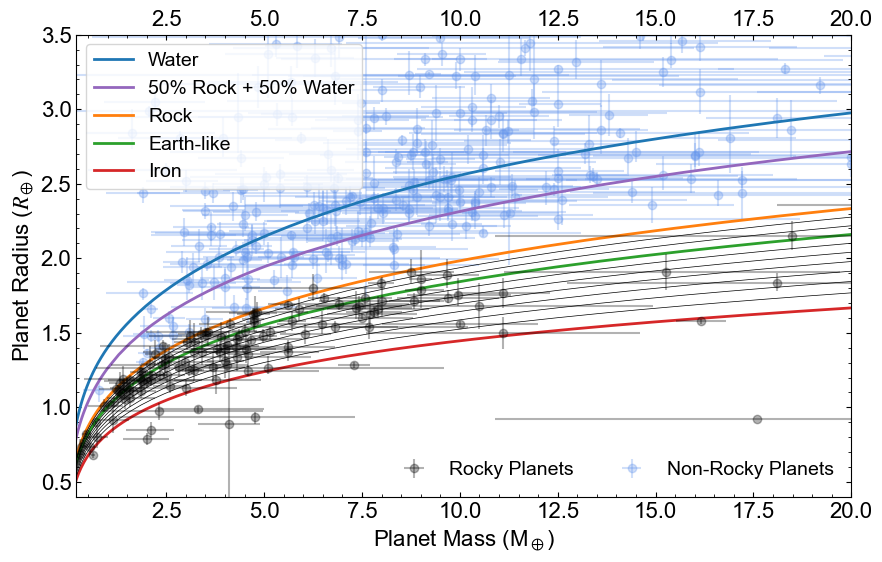

In [13]:
# plot CORGI M-R curves and the rho_HD curve
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# plot M-R curves with various compositions
# pure water
ax.plot(corgi_mr_water[:,1], corgi_mr_water[:,2], lw=2, label="Water", color=mr_colors[0])
# 50% rock, 50% water
ax.plot(corgi_mr_50rock_50water[:,1], corgi_mr_50rock_50water[:,2], lw=2, label="50% Rock + 50% Water", 
        color=mr_colors[4])
# pure rock
ax.plot(corgi_mr_cmf00[:,1], corgi_mr_cmf00[:,2], lw=2, label="Rock", color=mr_colors[1])
# Earth-like 30% CMF
ax.plot(corgi_mr_cmf03[:,1], corgi_mr_cmf03[:,2], lw=2, label="Earth-like", color=mr_colors[2])
# iron
ax.plot(corgi_mr_cmf10[:,1], corgi_mr_cmf10[:,2], lw=2, label="Iron", color=mr_colors[3])
# other MR curves as thin lines
ax.plot(corgi_mr_cmf01[:,1], corgi_mr_cmf01[:,2], "k-", lw=0.5)
ax.plot(corgi_mr_cmf02[:,1], corgi_mr_cmf02[:,2], "k-", lw=0.5)
ax.plot(corgi_mr_cmf04[:,1], corgi_mr_cmf04[:,2], "k-", lw=0.5)
ax.plot(corgi_mr_cmf05[:,1], corgi_mr_cmf05[:,2], "k-", lw=0.5)
ax.plot(corgi_mr_cmf06[:,1], corgi_mr_cmf06[:,2], "k-", lw=0.5)
ax.plot(corgi_mr_cmf07[:,1], corgi_mr_cmf07[:,2], "k-", lw=0.5)
ax.plot(corgi_mr_cmf08[:,1], corgi_mr_cmf08[:,2], "k-", lw=0.5)
ax.plot(corgi_mr_cmf09[:,1], corgi_mr_cmf09[:,2], "k-", lw=0.5)

# plot planets as scatter points
for i in data_planets.index.to_list():
    # rocky exoplanets
    if data_planets["p_rocky"][i] >= 0.32:
        colori = "k"
        alphai = 0.3
        zorderi = 2
    # non-rocky exoplanets
    else:
        colori = "#6495ED"
        alphai = 0.3
        zorderi = 1
    
    ax.errorbar(data_planets["planet_mass"][i]*Mjup/Me, data_planets["planet_radius"][i]*Rjup/Re,
                xerr=[[data_planets["planet_mass_lower"][i]*Mjup/Me], 
                      [data_planets["planet_mass_upper"][i]*Mjup/Me]],
                yerr=[[data_planets["planet_radius_lower"][i]*Rjup/Re], 
                      [data_planets["planet_radius_upper"][i]*Rjup/Re]],
                marker='o', color=colori, alpha=alphai, zorder=zorderi)

legend1 = plt.legend(loc="upper left", fontsize=14, fancybox=True, framealpha=0.8)
ax.add_artist(legend1)  # keep this legend when adding another

# 2nd legend for error bars
planets_rocky = ax.errorbar([0], [0], [3], [3], marker='o', color="k", alpha=0.3, linestyle="",
                            label="Rocky Planets")
planets_nonrocky = ax.errorbar([0], [0], [3], [3], marker='o', color="#6495ED", alpha=0.3, linestyle="",
                               label="Non-Rocky Planets")
legend2 = ax.legend(handles=[planets_rocky, planets_nonrocky], loc='lower right', 
                    fontsize=14, fancybox=True, framealpha=0, ncol=2)

ax.set_xlim([0.2, 20])
ax.set_ylim([0.4, 3.5])
ax.set_xlabel(r'Planet Mass (M$_\oplus$)', fontsize=16)
ax.set_ylabel(r'Planet Radius ($R_\oplus$)', fontsize=16)
ax.tick_params(axis='both', which='both', labelsize=16, top=True, right=True, direction='in', 
                   labeltop=True)
ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))

plt.savefig("Plots/MR_curves_with_planets.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close()